In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_excel("C:/Users/SIVAGAMI/Downloads/Solar Energy.xlsx")

In [3]:
print(df.shape)

(218115, 17)


In [4]:
missing_counts = df.isnull().sum().sort_values(ascending=False)

In [5]:
missing_summary = pd.DataFrame({
    "Missing Values": missing_counts,
    
})

print("Missing Values Summary:")
print(missing_summary)


Missing Values Summary:
                                             Missing Values
Energy Storage System Size (kWac)                    214024
Division                                              85234
Substation                                            79944
Developer                                             10550
Metering Method                                         463
Zip                                                      96
City/Town                                                58
Circuit ID                                               30
Project ID                                                3
Data Through Date                                         0
County                                                    0
Interconnection Date                                      0
Utility                                                   0
Estimated PV System Size (kWdc)                           0
PV System Size (kWac)                                     0
Estimated Annual

In [6]:
cat_cols = ["Developer", "Metering Method", "City/Town", "County", "Utility"]
for col in cat_cols:
    df[col] = df[col].fillna("Unknown")

In [7]:
df["Zip"] = df["Zip"].fillna(df["Zip"].median())

In [8]:
df["Interconnection Date"] = pd.to_datetime(df["Interconnection Date"], errors="coerce")
df["Data Through Date"] = pd.to_datetime(df["Data Through Date"], errors="coerce")

In [9]:
df["Project ID"] = df["Project ID"].fillna(df["Project ID"].mode())

In [10]:
df["Circuit ID"] = df["Circuit ID"].fillna(df["Circuit ID"].mode())

In [11]:
df.drop(columns=[
    "Division",
    "Substation",
    "Energy Storage System Size (kWac)"
], inplace=True)

In [12]:
print(df.isnull().sum())

Data Through Date                               0
Project ID                                      3
Interconnection Date                            0
Utility                                         0
City/Town                                       0
County                                          0
Zip                                             0
Circuit ID                                     30
Developer                                       0
Metering Method                                 0
Estimated PV System Size (kWdc)                 0
PV System Size (kWac)                           0
Estimated Annual PV Energy Production (kWh)     0
Number of Projects                              0
dtype: int64


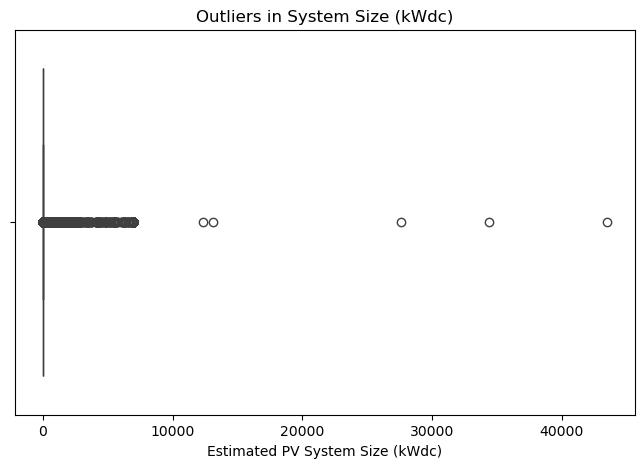

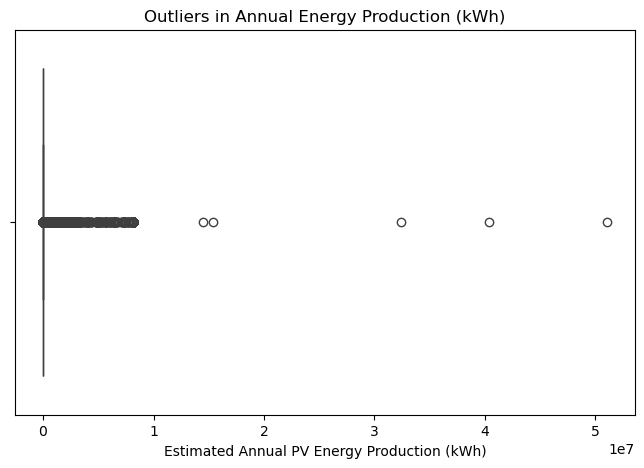

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x=df["Estimated PV System Size (kWdc)"])
plt.title("Outliers in System Size (kWdc)")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x=df["Estimated Annual PV Energy Production (kWh)"])
plt.title("Outliers in Annual Energy Production (kWh)")
plt.show()

In [14]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    cleaned_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    print(f"{column}: Removed {(len(df)-len(cleaned_df))} outliers")
    return cleaned_df

In [15]:
df = remove_outliers_iqr(df, "Estimated PV System Size (kWdc)")
df = remove_outliers_iqr(df, "PV System Size (kWac)")
df = remove_outliers_iqr(df, "Estimated Annual PV Energy Production (kWh)")

Estimated PV System Size (kWdc): Removed 12837 outliers
PV System Size (kWac): Removed 3579 outliers
Estimated Annual PV Energy Production (kWh): Removed 745 outliers


In [16]:
df[["Estimated PV System Size (kWdc)",
    "Estimated Annual PV Energy Production (kWh)"]].describe()

,Estimated PV System Size (kWdc),Estimated Annual PV Energy Production (kWh)
count,200954.000000,200954.000000
mean,7.418353,8707.773515
std,2.999464,3521.040594
min,0.010000,14.000000
25%,4.970000,5837.000000
50%,7.020000,8240.000000
75%,9.160000,10754.000000
max,15.370000,18046.000000


In [17]:
print("After cleaning:", df.shape)
print(df[["Estimated PV System Size (kWdc)",
          "Estimated Annual PV Energy Production (kWh)"]].describe())

After cleaning: (200954, 14)


       Estimated PV System Size (kWdc)  \
count                    200954.000000   
mean                          7.418353   
std                           2.999464   
min                           0.010000   
25%                           4.970000   
50%                           7.020000   
75%                           9.160000   
max                          15.370000   

       Estimated Annual PV Energy Production (kWh)  
count                                200954.000000  
mean                                   8707.773515  
std                                    3521.040594  
min                                      14.000000  
25%                                    5837.000000  
50%                                    8240.000000  
75%                                   10754.000000  
max                                   18046.000000  


In [18]:
from datetime import datetime


In [19]:
df["Interconnection Date"] = pd.to_datetime(df["Interconnection Date"], errors="coerce")

df["Interconnection_Year"] = df["Interconnection Date"].dt.year
df["Interconnection_Month"] = df["Interconnection Date"].dt.month

In [20]:
df["Data Through Date"] = pd.to_datetime(df["Data Through Date"], errors="coerce")
df["Project_Age_Years"] = (
    (df["Data Through Date"] - df["Interconnection Date"]).dt.days / 365
).fillna(0)

In [21]:
df["Yield_kWh_per_kW"] = (
    df["Estimated Annual PV Energy Production (kWh)"] / df["Estimated PV System Size (kWdc)"]
)

In [22]:
df["Capacity_Factor"] = (
    df["Estimated Annual PV Energy Production (kWh)"] /
    (df["Estimated PV System Size (kWdc)"] * 8760))

In [23]:
df["log_kWdc"] = np.log1p(df["Estimated PV System Size (kWdc)"])
df["log_kWh"] = np.log1p(df["Estimated Annual PV Energy Production (kWh)"])

In [24]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ["Developer", "Utility", "Metering Method", "County", "City/Town",]
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [25]:

df["System_Scale"] = np.where(df["Estimated PV System Size (kWdc)"] > 100, "Large", "Small")

In [26]:
target = "Estimated Annual PV Energy Production (kWh)"
drop_cols = [
    "Project ID", "Data Through Date", "Interconnection Date",
    target
]

X = df.drop(columns=drop_cols)
y = df[target]

print("Final Feature Shape:", X.shape)

Final Feature Shape: (200954, 18)


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (160763, 18)
Testing samples: (40191, 18)


In [29]:
non_numeric_cols = X.select_dtypes(include=['object']).columns
print("Columns with strings:", non_numeric_cols.tolist())

Columns with strings: ['Circuit ID', 'System_Scale']


In [30]:
X_train = X_train.drop(columns=["Circuit ID", "System_Scale"])
X_test = X_test.drop(columns=["Circuit ID", "System_Scale"])

In [31]:
X = pd.get_dummies(X, columns=non_numeric_cols, drop_first=True)

In [32]:
print(X.dtypes)

Utility                    int64
City/Town                  int64
County                     int64
Zip                      float64
Developer                  int64
                          ...   
Circuit ID_0416RO5106       bool
Circuit ID_5206631          bool
Circuit ID_0082RO5169       bool
Circuit ID_4303501          bool
Circuit ID_8100603          bool
Length: 6013, dtype: object


In [33]:
for col in X.columns:
    if X[col].dtype == 'object':
        print(col, X[col].unique()[:5])

In [34]:

df.drop(columns=["Circuit ID"], inplace=True)

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor


In [36]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

In [37]:
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))


R²: 0.9999999355191926
MAE: 0.4274047614812878


In [38]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [39]:
print("R²:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))


R²: 0.9999999894639815
MAE: 0.024352591376177967


In [40]:
dt = DecisionTreeRegressor(
    max_depth=10,      # limit depth to prevent overfitting
    min_samples_split=10,
    random_state=42
)

# Train
dt.fit(X_train, y_train)

# Predict
y_pred_dt = dt.predict(X_test)

In [41]:
r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)

In [42]:
print(f"Decision Tree → R²: {r2_dt:.3f}, MAE: {mae_dt:.2f}, ")

Decision Tree → R²: 1.000, MAE: 0.49, 


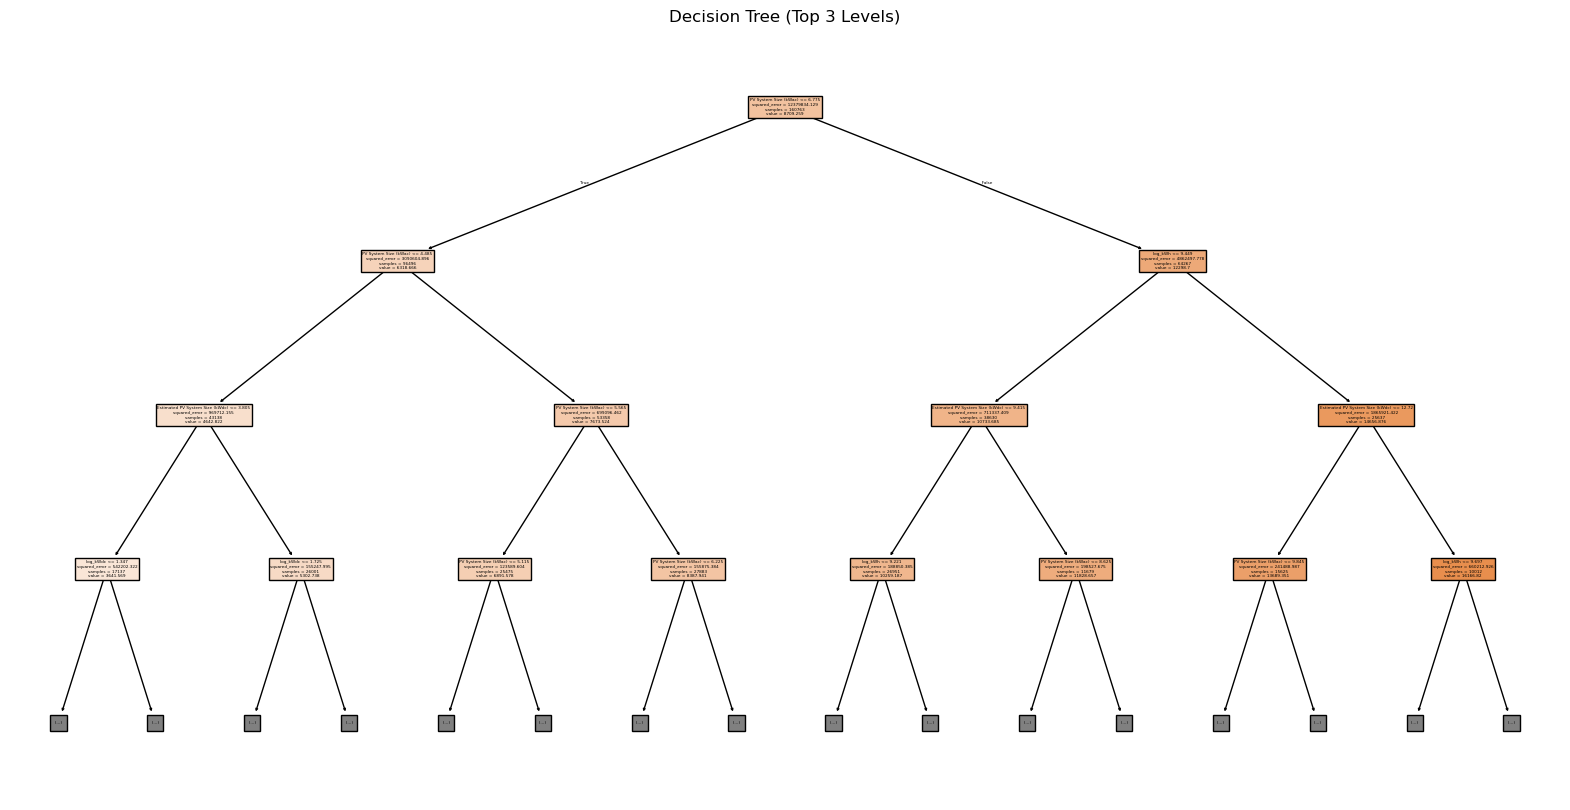

In [43]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dt, filled=True, feature_names=X.columns, max_depth=3)
plt.title("Decision Tree (Top 3 Levels)")
plt.show()

In [44]:
# Calculate metrics for Linear Regression
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

# Calculate metrics for Random Forest
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "R²": [r2, r2_dt, r2_rf],
    "MAE": [mae, mae_dt, mae_rf],
})

print(results)

               Model   R²       MAE
0  Linear Regression  1.0  0.427405
1      Decision Tree  1.0  0.486255
2      Random Forest  1.0  0.024353


In [45]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error

In [46]:
param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['squared_error', 'friedman_mse']
}

In [47]:
dt = DecisionTreeRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring='r2',     # or 'neg_mean_absolute_error'
    cv=5,             # 5-fold cross-validation
    n_jobs=-1,        # use all CPU cores
    verbose=2
)

In [48]:
grid_search.fit(X_train, y_train)

print("✅ Best Parameters Found:")
print(grid_search.best_params_)

print("\nBest R² Score (CV):", grid_search.best_score_)

Fitting 5 folds for each of 160 candidates, totalling 800 fits
✅ Best Parameters Found:
{'criterion': 'squared_error', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best R² Score (CV): 0.9999999373649846


In [49]:
best_dt = grid_search.best_estimator_

y_pred_dt = best_dt.predict(X_test)

r2 = r2_score(y_test, y_pred_dt)
mae = mean_absolute_error(y_test, y_pred_dt)

print(f"Decision Tree (Tuned) → R²: {r2:.3f}, MAE: {mae:.2f}, ")

Decision Tree (Tuned) → R²: 1.000, MAE: 0.03, 


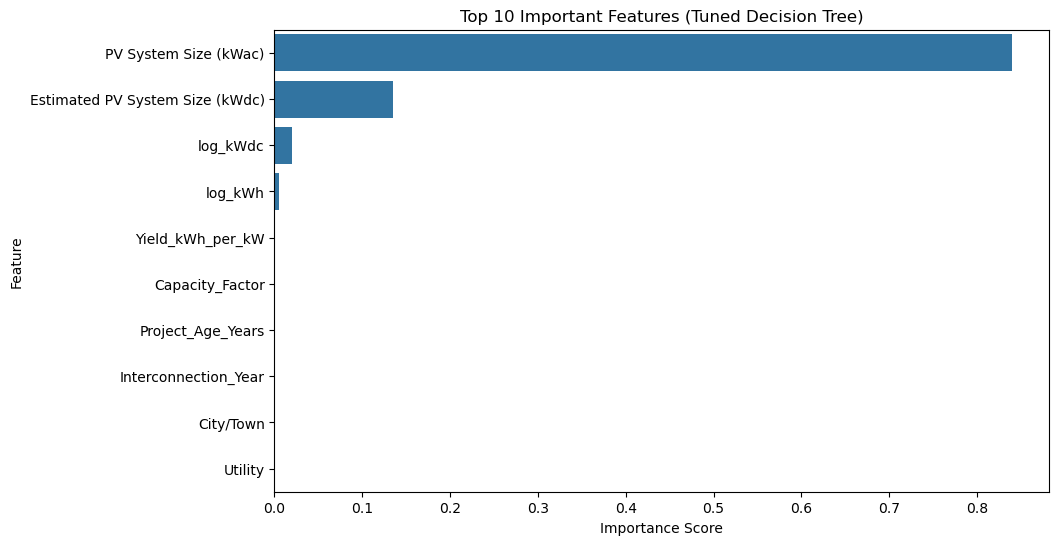

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

feat_imp = pd.Series(best_dt.feature_importances_, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp[:10], y=feat_imp.index[:10])
plt.title("Top 10 Important Features (Tuned Decision Tree)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

In [51]:
import joblib

joblib.dump(rf, "solar_energy_model.pkl")
print("✅ Model saved successfully!")

✅ Model saved successfully!


In [52]:
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [53]:
import streamlit as st
import pandas as pd
import joblib

# Load trained model
model = joblib.load("solar_energy_model.pkl")

st.set_page_config(page_title="Solar Energy Predictor", page_icon="🌞", layout="centered")

st.title("🌞 Solar Energy Production Predictor")
st.markdown("Estimate **annual energy production (kWh)** for new solar installations.")

# --- Input Fields ---
developer = st.text_input("Developer Name")
utility = st.text_input("Utility Company")
system_size = st.number_input("Estimated PV System Size (kWdc)", min_value=0.1, value=5.0)
system_size_ac = st.number_input("PV System Size (kWac)", min_value=0.1, value=4.5)
metering = st.selectbox("Metering Method", ["Net Metering", "Gross Metering", "Unknown"])
year = st.number_input("Interconnection Year", min_value=2000, max_value=2030, value=2024)

# --- Create Input DataFrame ---
input_data = pd.DataFrame({
    "Developer": [developer],
    "Utility": [utility],
    "Estimated PV System Size (kWdc)": [system_size],
    "PV System Size (kWac)": [system_size_ac],
    "Metering Method": [metering],
    "Interconnection_Year": [year]
})


# --- Prediction ---
if st.button("🔮 Predict Energy Production"):
    prediction = model.predict(input_data)[0]
    st.success(f"Estimated Annual Energy Production: **{prediction:,.0f} kWh/year**")


2025-10-13 08:48:59.041 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-13 08:48:59.042 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-13 08:48:59.571 
  command:

    streamlit run c:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-10-13 08:48:59.571 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-13 08:48:59.572 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-13 08:48:59.573 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-13 08:48:59.573 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [54]:
pip install gradio joblib scikit-learn pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [55]:
import joblib
joblib.dump(best_dt, "solar_energy_model.pkl")
print("✅ Model saved as solar_energy_model.pkl")

✅ Model saved as solar_energy_model.pkl


In [56]:
import gradio as gr
import pandas as pd
import joblib

# Load the trained model
model = joblib.load("solar_energy_model.pkl")

# Define prediction function
def predict_energy(developer, utility, system_size_kwdc, system_size_kwac, interconnection_year, metering_method):
    # Create a DataFrame matching your model's input schema
    input_data = pd.DataFrame({
        "Developer": [developer],
        "Utility": [utility],
        "Estimated PV System Size (kWdc)": [system_size_kwdc],
        "PV System Size (kWac)": [system_size_kwac],
        "Interconnection_Year": [interconnection_year],
        "Metering Method": [metering_method]
    })

    # ⚠️ Apply same preprocessing used during training (encoding, etc.)
    # For now, assuming your model can handle raw text or was trained with label encoding.

    prediction = model.predict(input_data)[0]
    return f"🔆 Predicted Annual Energy Production: {prediction:,.0f} kWh/year"

# Build Gradio Interface
app = gr.Interface(
    fn=predict_energy,
    inputs=[
        gr.Textbox(label="Developer Name"),
        gr.Textbox(label="Utility Company"),
        gr.Number(label="Estimated PV System Size (kWdc)", value=5.0),
        gr.Number(label="PV System Size (kWac)", value=4.5),
        gr.Number(label="Interconnection Year", value=2024),
        gr.Dropdown(["Net Metering", "Gross Metering", "Unknown"], label="Metering Method"),
    ],
    outputs=gr.Textbox(label="Predicted Energy Output (kWh/year)"),
    title="🌞 Solar Energy Production Predictor",
    description="Enter project details to estimate annual solar energy production using a trained Decision Tree model."
)

# Launch app
app.launch()


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [59]:
print("Running on local URL:  http://127.0.0.1:7860")


Running on local URL:  http://127.0.0.1:7860
